## Class Project: An Analysis of Gun Violence Data in the US (2014 to 2017)

## Introduction 




The level of gun violence in America is **high**. According to the John's Hopkins Bloomberg School of Public Healh, the firearm homicide rate in the U.S. is nearly **25 times higher than other high-income countries**. Through this project, my aim is to to explore and analyze the trends in **gun violence data across America from 2014 to 2017** with the goal of identifying statitics and producing visualizations that  help policymakers target and produce **effective legislation for the areas that are affected most**. Specifically, I aim to identify the cities and states with the highest number of shootings, when these shootings occur, and estimate the average age of a person who commits an act of gun violence.

For this project, I am using gun violence data from the following GitHub repository: https://github.com/jamesqo/gun-violence-data. This repository contains data for "all recorded gun violence incidents in the US between January 2013 and March 2018, inclusive," and it was sourced from a not for profit corporation entitled, Gun Violence Archive (GVA).

The data contains 222,215 incidents of gun violence, but the GitHub repository states the following:
- The list of incidents from 2013 is not exhaustive (only 279 incidents from that year were catalogued) and the data from 2018 is limited to the months of Jan-Mar. 
- Two incidents were manually removed from the dataset: the Las Vegas mass shooting incident which "had to be removed because information about the incident was stored in a PDF" and incident 1081885 which "had to be removed because the location details were not parsing nicely."

Please note:
- **In order to re-run the provided code, you must run the appendix first.**
- I will not be analyzing incidents from 2013 or 2018 because their limited responses may skew the data (especially looking at annual totals). I drop these instances when cleaning the data. 

I cannot seem to find examples of analyses using this repository specifically. However, the Gun Violence Archive website contains a host of visualizations and statistics: https://www.gunviolencearchive.org/. Additionally, many similar gun violences analyses have been done, such as the aforementioned analysis conducted at John's Hopkins: https://publichealth.jhu.edu/center-for-gun-violence-solutions/research-reports/gun-violence-in-the-united-states.


## Data wrangling: Preparation for Visualization


**Step 1: Import Packages and Data**

I first imported the following packages: numpy, pandas, seaborn, geopandas, and matplotlib.pyplot. 
a then read into the Jupyter directory the dataset on gun violence, `raw_gun_data`, and the dataset containing a map of the US, `usa`.

**Step 2: Clean the Gun Violence Data** 

I cleaned the data by ensuring that all data points had a citation with a URL, dropping unused columns, and dropping instances outside of the US and instances from 2013 and 2018 (to ensure that we are working with a full year's worth of data). I stored the clean data in a dataframe called `gun_data`. 

**Step 3: Extract a Map of Mainland USA**

Finally, I created a GeoDataFrame called `usa_mainland` by removing Alaska and Hawaii from the `USA` data. I also created a dataframe called `mainland_gun_data` to store  shootings that occured in the Contiguous US. This was done in order to visualize as much data as possible while keeping the graph visually digestible. 

I built a series of additional functions (not visualized in this paper) in that allow for further state-by-state analyses (see appendix): 

- `stateGeoDataFrame(state_name)`: returns the gun data of a given state 
- `stateGunData(state_name)`: returns the GeoDataFrame of a given state from the USA data
- `mapStateGunData(state_name)`: plots a given state with its incidents of gun violence

Other variables are used throughout the project; notable ones will be explained under each subsection.

## Visualization 1: Where are  shootings happening the most? Part 1

This map visualizes the geographic distribution of shootings across the Contiguous US from the 2014-2017. Each red-point represents an incident of gun violence, and the 20 cities with the most shootings are labeled. The location of each label is determined by averaging the coordinates of each incident in that city, so each label is centered over each city's epicenter of gun violence.

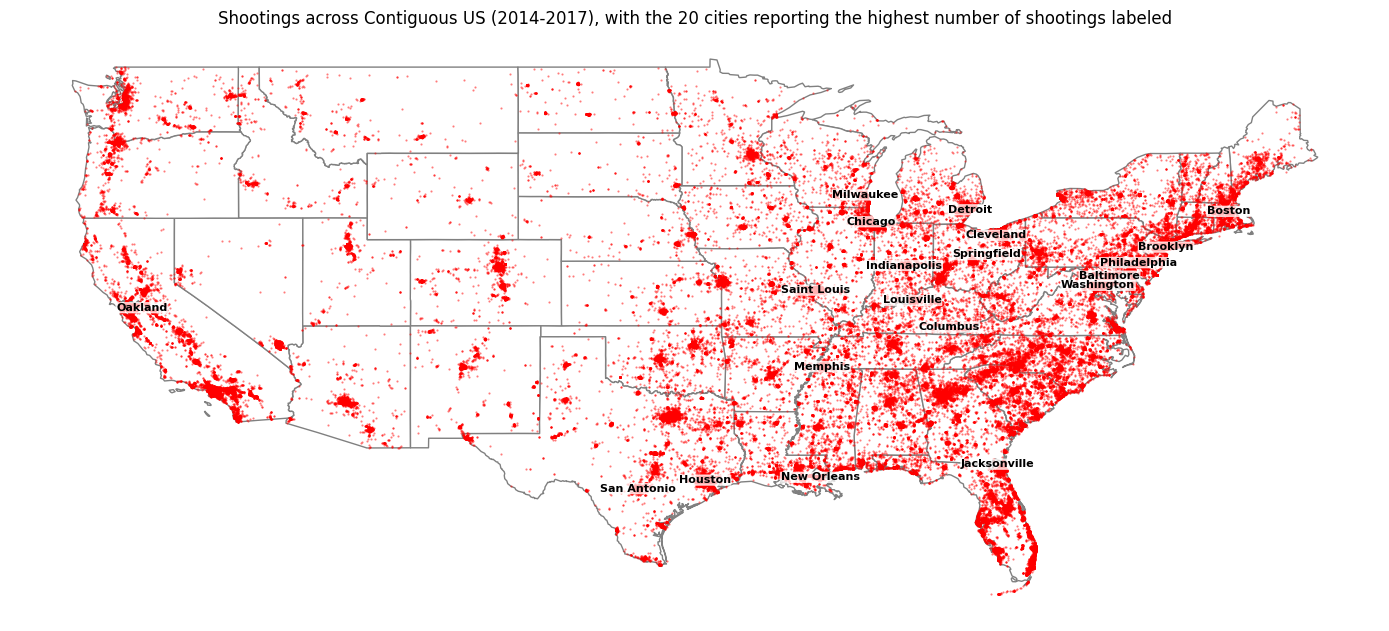

In [4]:
fig, axes = plt.subplots(1, 1, figsize = (14, 10)) 

usa_mainland.plot(ax = axes, color = 'white', edgecolor = 'gray') #plotting outline of mainland US
mainland_gun_data.plot(ax = axes, markersize = 0.3, color = 'red', alpha = 0.5) 
axes.set_title('Shootings across Contiguous US (2014-2017), with the 20 cities reporting the highest number of shootings labeled')

t20city_counts = city_counts[0:20] #labeling each city
for index,row in t20city_counts.iterrows():
    axes.text(row['longitude'], row['latitude'], row['city_or_county'], color = 'k', fontweight='bold', ha = 'center', va = 'center', fontsize = 8, bbox = dict(facecolor = 'white', alpha = 0.7, edgecolor = 'white', boxstyle = 'round, pad = 0'))
axes.set_axis_off(); plt.tight_layout(); plt.show()

**Analysis 1:**
The map above provides insight into the concentration of reported shootings across America. The red points clearly show that gun violence is not evenly distributed across the country, but is instead concentrated in dense clusters corresponding to large metropolitan areas. High density zones line the East Coast and Midwest. The largest hotspots are concentrated in the Midwest (Chicago, Detroit...), the Mid-atlantic (Baltimore, Philadelphia...), Texas, and Florida. Conversely, the great plains have very few data points, indicating a strong correlation between population density and the frequency of recorded gun violence incidents. 

## Visualization 2: Where are  shootings happening the most? Part 2

**For the remainder of the project, we will be analyzing data from all 50 states.**

Building on the last visualization, this one shows the total number of shootings from 2014-2017 for each state & for each of the 50 cities/counties with the most reported gun violence. Each graph is ranked from highest to lowest reported gun violence incidents. Additionally, the color of each bar is determined by its relative count (as shown by the legend). 

<bound method Figure.tight_layout of <Figure size 1000x600 with 2 Axes>>

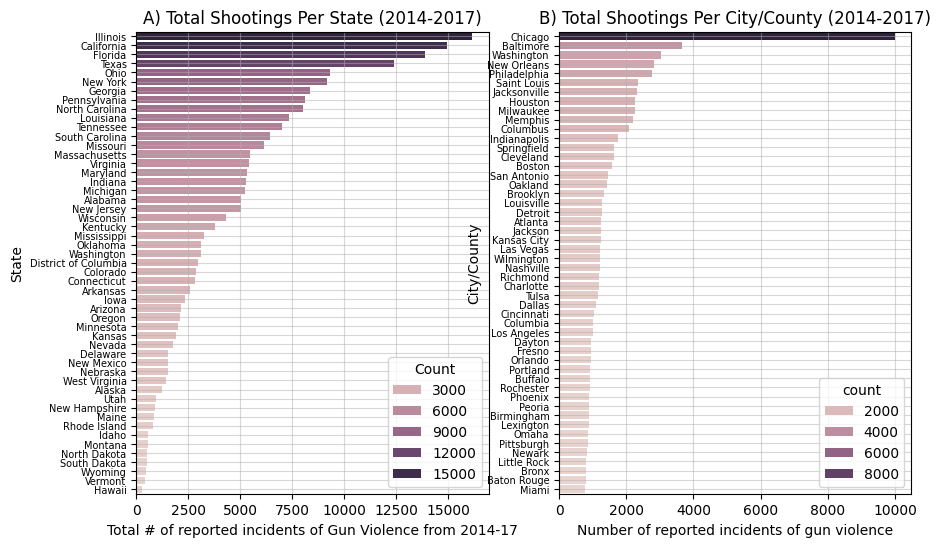

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (10, 6))

#Plot A: Shootings Per State
sns.barplot(ax=axes[0], data = sum_of_state_shootings, x = 'count', y = 'state', hue = "count")
axes[0].grid(True, linestyle='-', alpha=0.5)
axes[0].tick_params(axis='y', labelsize=7)
axes[0].set_xlabel('Total # of reported incidents of Gun Violence from 2014-17')
axes[0].set_ylabel('State')
axes[0].set_title('A) Total Shootings Per State (2014-2017)')
axes[0].legend(title = 'Count')

sns.barplot(ax = axes[1], data = city_counts[0:50], x = 'count', y = 'city_or_county', hue = "count")
axes[1].grid(True, linestyle='-', alpha = 0.5)
axes[1].tick_params(axis = 'y', labelsize= 7)
axes[1].set_xlabel('Number of reported incidents of gun violence')
axes[1].set_ylabel('City/County')
axes[1].set_title('B) Total Shootings Per City/County (2014-2017)')
axes[1].legend(title = 'count')
fig.tight_layout


In [6]:
print(f"Chicago has had {round(city_counts.loc[0]["count"] / city_counts.loc[1]["count"], 3)}x as many shootings as the next most violent city.")
print(f"Chicago makes up {100*round(city_counts.loc[0]["count"] / sum_of_state_shootings.loc[0]["count"], 3)}% of all shootings in Illinois.")

Chicago has had 2.731x as many shootings as the next most violent city.
Chicago makes up 61.9% of all shootings in Illinois.


Analysis 2: This visualization highlights how differently gun-violence incidents are distributed across states and across cities/counties. On the left, the 4 states with the most incidents are within a relatively close range of one another. Conversely, on the right, Chicago (the city with the most gun violence) has 2.731 times as many shootings as the next highest city. This suggests Chicago is in especially urgent need of mitigation efforts and gun reform. Furthermore, since Chicago had nearly 10,000 shootings from 2014-17, it makes up nearly 62% of all shootings in Illinois, despite making up <25% of the population in Illinois. This is important insight for policymakers that would not have been captured in just one graph. 

## Visualization 3: When do shootings most frequently occur?


Before visualizing the data, it must be sorted into two different variables:
- `shootings_over_time`: Used in the first graph, this is a DataFrame that contains information on `year_month` and `count` to show # of incidents per month and year (stored in a single column). 
- `shootings_per_month`: this is a DataFrame that contains the same information but stored `year` and `month` in seperate columns.

In [7]:
gun_data['year'] = gun_data['date'].str[:4]
gun_data['month'] = gun_data['date'].str[5:7]
gun_data['year_month'] = gun_data['date'].str[:7]

shootings_over_time = gun_data.groupby(['year_month']).size().reset_index().rename(columns={0: 'count'})
shootings_per_month = gun_data.groupby(['year', 'month']).size().reset_index().rename(columns={0: 'count'})

The following visualization has 2 parts:

a) The Number of Monthly Shootings Across US (Over Full Time Period)
- The x-axis shows each month from January 2014 to December 2017.
- The y-axis shows the number of reported incidents of gun violence.
- Each red point represents the average # of reported incidents across America for a given month, and they are connected month to month.
- The red line is a line of best fit, surrounded by a 95% confidence interval.

b) Average Number of Shootings per Day by Month, Across US, Overlaid by Year (2014-2017)
- The x-axis shows each month from January to December.
- The y-axis shows the average number of reported incidents of gun violence per day.
- Each line represents a different year.

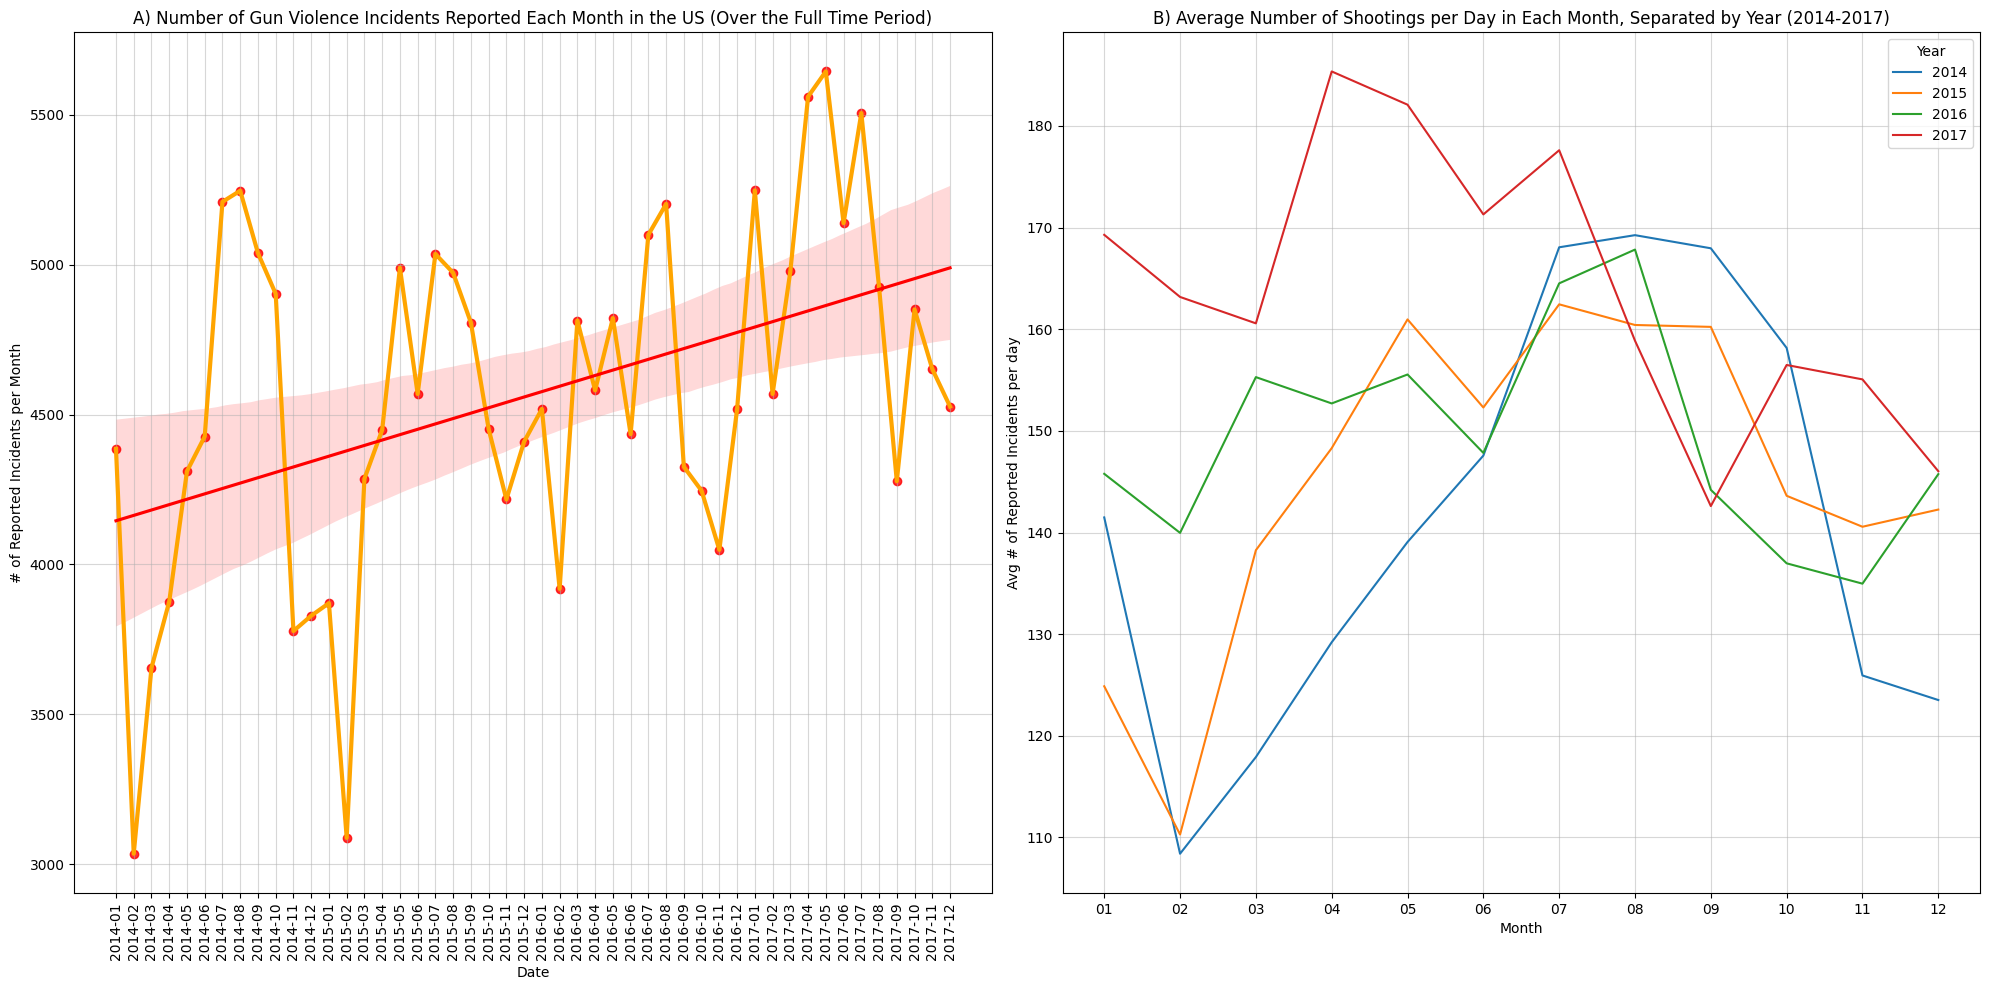

In [8]:
fig, axes = plt.subplots(1, 2, figsize = (20, 10))

#Left plot
sns.lineplot(data = shootings_over_time, x = 'year_month', y = 'count', linewidth = 3, ax = axes[0], color = 'orange')
sns.regplot(data = shootings_over_time, x = shootings_over_time.index, y = 'count', ax= axes[0], color='red',  ci = 95) #Regressed line with confidence interval
axes[0].set_title('A) Number of Gun Violence Incidents Reported Each Month in the US (Over the Full Time Period)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('# of Reported Incidents per Month')
axes[0].grid(True, linestyle='-', alpha = 0.5)
axes[0].tick_params(axis = 'x', rotation = 90)

# Right plot
shootings_per_month['count_per_day'] = shootings_per_month['count'] / days_per_month
sns.lineplot(data = shootings_per_month, x = 'month', y = 'count_per_day', hue = 'year')
axes[1].set_title('B) Average Number of Shootings per Day in Each Month, Separated by Year (2014-2017)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg # of Reported Incidents per day')
axes[1].legend(title='Year')
axes[1].grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()

Graph A shows the total number of gun violence incidents reported each month in the US. While the monthly values fluctuate, the confidence band suggests a statistically significant upward trend over the four-year period, which is supported by the upward trend of the regressed line. In January 2014, the 95% confidence interval ranges from roughly 3,800 to 4,500, whereas by December 2017 the interval increases to roughly 4,750 to 5,250. Seeing as the top of the January 2014 interval is below the bottom of the December 2017 interval, can confidently conclude that the true population number of monthly shootings increased over time.

Graph (B) shows the average number of shootings per day in each month, separated by year. Across all four years, reported incidents generally peak in the summer (Jun to Aug) and decline in the winter (Dec to Feb). This may be due to people having more free time in the summer, being out of school, or being outside more often. Despite the seasonal ebb and flow, the general increase year-by-year suggests a gradual upward trend, supporting our analysis from the first graph. 

Together, the two graphs show that the US experienced seasonal fluctuations and general growth in number of gun violence reports from 2014-2017. The CI suggests that this increase is unlikely due to random chance, but rather a meaningful increase in gun violence reports.

## Visualization 4: What is the average age of someone who commits an act of gun violence?

Since the `participant_age` column of the `gun data` DataFrame is formatted unusually, I extract each age and and put them in a list called `ages`.

In [9]:
display(gun_data[['participant_age']].head(5))

all_listed_ages = gun_data['participant_age'].astype(str).str.replace('::', ',').str.replace('||', ',').str.split(',')
ages = []
for item in all_listed_ages:
    if item is not None:
        ages_per_incident = item[1::2]
        ages.extend([int(a) for a in ages_per_incident if a.isdigit()])

ages[0:5] #we now have a list of ages

,participant_age
0,NaN
1,NaN
2,0::22||1::26
3,0::34
4,0::6||1::12


[22, 26, 34, 6, 12]

With the new `ages` list, we can graph a kernel density estimation (KDE) to show the age distrution of gun violence offenders.
- The x-axis shows age (filed into 50 bins)
- The y-axis shows the number of reported incidents
- Mean, median, and mode are also plotted (as indicated in the legend)

The histogram and KDE curve visualize the ages of individuals involved in acts reported gun violence between 2014 and 2017. Because `mean` > `median`, the data is positively skewed (the older indivduals drag the mean higher than the median). This is visualized on the graph, as most of the data is on the left side, with fewer and fewer values on the right. `mode = 19` suggests that early adulthood is the age with the highest number of gun violence offenders. The steep decline after ~25 suggests that the likelihood of gun violence drops sharply with age. Overall, the graph shows that gun violence offences are highly concentrated among young adults, and they generally decline as age increases. To combat this, policymakers could enforce stricter gun regulations and registration requirements for those ages 18-30. Background checks, firearm education, and safe-carry legislation could help minimize the number of guns sold, keep guns away from those who are not registered, and keep guns out of the hands of those who are prone to violence. This would help mitigate the number of intenital and unintentional acts of gun violence. 

Mean = 29.45 
Median = 26.0 
Mode = 19 


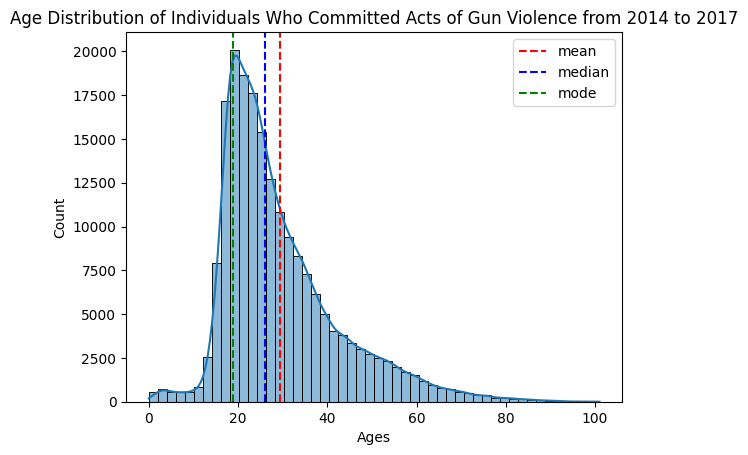

In [10]:
ages_series = pd.Series(ages, name = "Ages")
ages_series = ages_series[ages_series < 120] #due to the datasets size, there are a handful of incorrect ages over 120 years old. 

age_counts = ages_series.value_counts()
mean = ages_series.mean()
median = ages_series.median()
mode = ages_series.mode()[0]

sns.histplot(ages_series, bins=50, kde = True)
plt.axvline(x = mean, color='red', linestyle='--', linewidth = 1.5, label = 'mean')
plt.axvline(x = median, color='blue', linestyle='--', linewidth = 1.5, label='median')
plt.axvline(x = mode, color='green', linestyle='--', linewidth =1.5, label='mode')
plt.title("Age Distribution of Individuals Who Committed Acts of Gun Violence from 2014 to 2017")
plt.legend()

print(f"Mean = {round(mean, 2)} \nMedian = {median} \nMode = {mode} ")

## Conclusions

This report highlights a series of important geographic, temporal, and demographic statistics and trends regarding gun violence in the United States from 2014-2017. 

Geographically, reports of gun violence incidents were manily concentrated on the Eastern side of the US. Most incidents occured in the midwest and mid-atlantic, with the states of Hawaii, Vermont, and Wyoming reporting the least total number of shootings, and Illinois, California, & Florida reporting the most. Intuitively, states with higher populations tended to report more shootings. This is likely due to their being more people to commit shootings, but policymakers should also consider other factors of the rural/urban divide (such police presence which could affect report-rates or firearm ownership rates). Chicago was the city with the most reported shootings—by a lot. The data analysis found that Chicago reported 2.731 times as many shootings next city, Baltimore, and constituted nearly 62% of all shootings in Illinois (despite constituting only 225. This suggests that Chicago is very most in need of gun violence legislation. 

Temporally, gun violence incidents show strong seasonal fluctuations, with higher frequencies in the summer (June–August) and lower frequencies in the winter (Dec-Feb). This trend is observed all 4 years, and it may occur due to a summertime increase in free-time, students being out of school, or people generally being outside more often. Despite the seasonal ebb and flow, there was a statistically significant upward trend in the total number of monthly shootings, as indicated by the positive regression line and non-overlapping confidence intervals between early 2014 and late 2017. This highlights in the increasingly pressing issue of gun violence in America, suggesting that (unless change is made) the issue will continue to rise in severity. 

Demographically, the data-set was challenging to interpret due to it's structure. However, important statistics regarding age were collected. Notably,the mean age of a gun violence offender was approximately 29 years, with a median of 26, and a mode of 19, showing that offenders are predominently younger individuals. Visually, there is a stark increase in gun violence right after age 18, with few older indivuals skewing the distribution. Intuitively, this makes sense because American's are allowed to purchase a gun at age 18. However, this does not explain the disproportionate amount of shootings done by young adults, so legislators should look to influencing factors such as lack of brain development, the youth mental health crisis, and access to weapons in the home. Additionally, they should look for connecting trends, such as how the low average age of a gun violence offender could be tied to the increase in summertime violence while students are out of school and parents are at work.

Overal, these geographic, temporal, and demographic trends show that gun violence in America is a concentrated, growing, and youth-driven problem. Addressing it will require targeted policies that consider high-risk cities, seasonal patterns, and the unique vulnerabilities of young adults.

## Reflection

Overall, the project draft was okay. At first, I was really excited to dig into the data, but I found myself cleaning the data more than making meaningful analyses. Had I chosen a more manageable dataset, I think I could have accomplished more meaningful results. That being said, I learned a lot doing this project. I spent many hours debugging and testing code. I am very proud of my age distribution, but I am disappointed that I couldn't extract accurate suicide data. I wrote this code to visualize the number of gun related suicides. However, the way the dataset is configured, searching for 'suicide' overcounts the true number. 

`mainland_suicides = mainland_gun_data[mainland_gun_data['incident_characteristics'].str.contains(r'suicide', na=False)]
suic_death = mainland_suicides[mainland_suicides['n_killed'] > 0]
mainland_death = mainland_gun_data[mainland_gun_data['n_killed'] > 0]
print(len(suic_death) / len(mainland_death))`

I ended up spending 25+ hours on the project draft.

As for my final project, I addressed all of the points made in the peer reviews by explaining why I removed outliers, adding additional analyses for Chicago, making the state_names more legible on visualization 1, correcting the state counts for visualization 2, and adding a substational conclusion. I did not add a hypothesis test or machine learning because the dataset was so large, but I did add a 95% confidence interval to visualization 3 to prove the statistical significant upward trend in number of reported incidents over time. I would guess that I spent around 30 hours on this project, and I had a lot of fun doing it. Thank you to the faculty member who is grading this, and thank you to the teaching team!

## Appendix

In [3]:
#STEP 1: Import Packages and Data

import YData
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline

raw_gun_data = pd.read_csv("gunViolenceDataset.csv") #raw gun violence data
usa = gpd.read_file('States_shapefile.geojson') #map of usa
usa = usa.drop(columns = ["FID", "Program", "Flowing_St", "FID_1"]) #remove unnecessary columns


#STEP 2: Clean the gun violence data

print(f"Number of datapoints that do not have a URL citation: { sum(raw_gun_data['incident_url_fields_missing']) } \n") # Ensure that all data points are properly cited with a URL
gun_data = raw_gun_data.drop(columns = ['incident_id', 'incident_url', 'source_url', 'incident_url_fields_missing', 'gun_stolen', 'participant_type', 'sources']) #drop unused columns
inside_USA = gun_data['longitude'] < 0 #drop instances outside of the US 
gun_data = gun_data[inside_USA] 

mask2013 = ~gun_data["date"].str.contains('2013', na=False) #drop instances from 2013 and 2018 since they are limited and would be treated as outliers
gun_data = gun_data[mask2013]
mask2018 = ~gun_data["date"].str.contains('2018', na=False)
gun_data = gun_data[mask2018].reset_index()


gun_geoData = gpd.points_from_xy(gun_data['longitude'], gun_data['latitude']) #create geopandas dataset
gun_data = gpd.GeoDataFrame(gun_data, geometry = gun_geoData)


#STEP 3: Extract the map data for Alaska and Hawaii¶

def stateGeoDataFrame(state_name): #function that returns the GeoDataFrame of a given state from the USA data
    return usa.query(f"State_Name == '{state_name.upper()}'")

def stateGunData(state_name): #function that returns the gun data of a given state
    return gun_data.query(f"state == '{state_name}'")

def mapStateGunData(state_name): #function that maps the gun data of a given state;  capitalize the parameter for `state_name` (e.g. Illinois)
    fig, axes = plt.subplots(1,1, figsize = (7,7))
    stateGeoDataFrame(state_name.upper()).plot(ax = axes,color='white', edgecolor = 'black')
    stateGunData(state_name).plot(ax = axes,markersize = 0.2, color = 'blue', alpha = 0.5)

alaska = stateGeoDataFrame('ALASKA')
hawaii = stateGeoDataFrame('HAWAII')
usa_mainland = usa.drop(hawaii.index[0]).drop(alaska.index[0]) #creates GeoDataFrame for mainland USA by dropping the Hawaii and Alaska

temp_mask = gun_data['longitude'] > -125 #Creates a boolean mask to isolate the datapoints that are only on mainland USA (east of longitude -125)
mainland_gun_data = gun_data[temp_mask]



#VISUALIZATIONS: calculating citys' counts and their coordinates
days_per_month = np.array(4*[31,28,31,30,31,30,31,31,30,31,30,31])

sum_of_state_shootings = gun_data['state'].value_counts().reset_index().sort_values("count", ascending = False) #this gives the total number of shootings from 2014-2017 for each state
city_coordinates = (
    gun_data.groupby('city_or_county')[['latitude', 'longitude']]
    .mean()
    .reset_index() # Convert the index back to a column
)
city_counts = (
    gun_data.groupby('city_or_county')
    .size()                          
    .reset_index(name='count')       
    .sort_values("count", ascending=False) 
)
city_counts = pd.merge(city_counts, city_coordinates, on='city_or_county', how='left')

Number of datapoints that do not have a URL citation: 0 



In [12]:
%%capture

# You can run this code to covert this Jupyter notebook into a pdf
!quarto render FinalProject.ipynb --cache-refresh --to pdf 

# Peer Review

#### Project writer name: Max Ringelstein
#### Project writer email address: max.ringelstein@yale.edu

#### Reviewer name: Kevin Hidalgo
#### Reviwer email address: kevin.hidalgo@yale.edu



# Summary

This project uses gun violence statistics to create different visualizations that show gun violence trends in America. The goal of the project is to identify what areas of the country and what age groups are in most need of policy to curb gun violence. The project also establishes the worrying fact that gun violence incidents have risen over time in America.



## 1. Overall strengths and weaknesses 

I think the project has great visualizations that are effective in answering the research question. The KDE, the 2 charts with the states and cities, and the daily vs monthly gun violence charts are all memorable and they look clean. The map of America, while very effective in presenting the data, could read better, especially with the city titles. 


## 2. Major revisions

- Per capita counts should be their own visualization. Don't replace visualization 2 like you plan to because both the current visualization 2 and the per capita version tell their own stories that aren't individually more important than the other. 



## 3. Minor revisions 

 - Visualization 2 needs a time reference on the title.
 - Visualization 1 is a bit hard to read. I like the red dots on the map because it's a stark image, but the titles of the cities are not the most legible.
 - Typos here and there "which is support by (analysis of visualization 3)" etc
 - In the wrangling, "Step 1: Clean the gun violence data I cleaned the..." should be something like "Step 1: Clean the gun violence data - I cleaned the..."
 - Not a lot of comments 





## 3. Rubric score

Introduction: 15/15
Data Cleaning: 12/12
Data Visualization: 21/23
Analyses: 20/23
Conclusions: 12/12
Review and Reflection: 12/12



#### Rubric items where points would be taken off if not addressed: 

- Visual appearance of graphs could be improved; i.e., missing labels, poor color choices, etc
- Project would benefit from an additional analyses
• Code is not neat or well commented 



### Total score:   92/97

## The rubric score here doesn't make sense to me. 15 + 12 + 23 + 23+ 12 + 12 is 97, not 90. Because of this, I will be grading on a 97 score.





#### Project writer name: Max Ringelstein
#### Project writer email address: max.ringelstein@yale.edu

#### Reviewer name: Pamela Kim
#### Reviewer email address: pamela.kim@yale.edu



# Summary

The main goal of this project is to analyze the trends of gun violence in America from 2014 to 2017; thus aiding policymakers to target and produce effective legislation for the areas that are affected the most from gun violence. With the database from GitHub that contains 222,215 incidents, the project writer was able to visualize the data and make it easier to interpret the data. One of the visualizations included a map that visualizes the geographic distribution of gun violence across the US from 2014 to 2017, which was super helpful to understand that gun violence is not evenly distributed across America (most of the dense clusters take place in large metropolitan areas). The top five states with the most number of reported incidents of gun violence of Illinois, California, Florida, Texas, and Ohio while the top five shootings per city/county are Chicago, Baltimore, Washington, New Orleans, and Philadelphia. Additionally, there ahve been seasonal fluctuations of gun violence, but a general growth in reports from 2014 to 2017, indicating that there have been an increase in shootings with time. Lastly, the histogram with the age distribution of individuals who committed acts of gun violence indicates have a peak at the age range of 16 - 2, which means that young adults have committed the most shootings, and decreases with age. 

## 1. Overall strengths and weaknesses 

I believe that this project is a very well done and thought through. The project throughouly covers many different aspects of gun violence such as the geographic distribution of shootings across the US, number of reported shootings in each state, county, and city, the number (and avg. number) of monthly, daily shootings, as well as the age of the shooter. I really found it interesting to see when these incidents occurred the most as well as the distribution of ages of the shooters. If the data was available, I believe that it would have been really cool to see when during the day the shootings occurred. This would help policy makers determine when the peak time of these shootings are; thus, strenghten enforcement during those times or more security or public safety personel to patrol more often during those times. I also feel like your project could benefit from understandng the number of people were killed or injured as well as the news source that reported the shooting (which are provided the dataset). Overall, I feel like this project was very well thought through and had a lot of interesting points covered. I really loved the map and your artistic choice to use red dots to indicate the geographical location of the shooting.

## 2. Major revisions

- Make sure to add a analysis section with a hypothesis test or any machine learning techniques we learned during class
- **This is not something I would take a point off of; however, as you said in the reflection section, I beleive that your project would benefit from having another data visualization that dives into a topic of your choice (if possible, the suicide data sounds very interesting)!

## 3. Minor revisions 

- There are a few grammatical errors in the project (for example: "whcih" in the introduction)
- Make sure to delete the instructions (such as the one in the reflection section)
- In the conclusion section, I think it would be super cool to see your recommendation for policy makers instead of only stating your observations and analysis for the data visualizations.


## 3. Rubric score

#### Rubric items where points would be taken off if not addressed: 

- Did not explain the reasoning for removing outliers, or did not remove outliers that are clearly
due to mistakes in the data (-2 point)
- Project would benefit from an additional analyses (-2 points)
- Conclusions reiterates test results with no significant insight given (-2 point)


### Total score:   84/90


#### I have yet to receive peer review from Lizeth Ortiz-Calleja. I will re-upload this assignment if I receive her feedback.